In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We do the same things that we did in "btc_std_calc_2_states.ipynb". Refer to that.

In [37]:
# Refer to "4_states_transitions_and_means.ipynb".
P = np.genfromtxt("mat_4_states.csv",delimiter=",")

In [38]:
P

array([[0.21537 , 0.418819, 0.268072, 0.097739],
       [0.085105, 0.451639, 0.43506 , 0.028196],
       [0.029322, 0.390083, 0.503568, 0.077026],
       [0.090701, 0.225392, 0.461751, 0.222156]])

$$\pi = [0.002312, 0.008625, 0.039261, 0.424289, 0.476712, 0.038519,
       0.008175, 0.002106]

In [39]:
pi = np.genfromtxt("pi_4_states.csv",delimiter=",")

In [40]:
pi

array([0.069005, 0.405745, 0.456652, 0.068598])

In [41]:
Pi = np.vstack([pi]*4)

In [42]:
Pi

array([[0.069005, 0.405745, 0.456652, 0.068598],
       [0.069005, 0.405745, 0.456652, 0.068598],
       [0.069005, 0.405745, 0.456652, 0.068598],
       [0.069005, 0.405745, 0.456652, 0.068598]])

Took $$ a(-2) = -20, a(-1) = -10,...  a(2) = 20. \implies a^* =  0.507268$$

In [43]:
# Again, refer to "4_states_transitions_and_means.ipynb".
a_star = 0.500957

In [44]:
a = np.linspace(start=-20,stop=20,num=5)
a = np.delete(a,2)

In [45]:
b = np.array(a-a_star)

In [46]:
b

array([-20.500957, -10.500957,   9.499043,  19.499043])

$$ g:= (P + \Pi^* -I){^-1} b$$

In [47]:
A= np.linalg.inv(P + Pi - np.eye(4))

In [48]:
print(A)

[[-1.04554714  0.79857071  1.1475782   0.09939937]
 [ 0.11801094 -0.2468207   0.94150649  0.18730421]
 [ 0.1873882   0.83140985 -0.14619489  0.12739669]
 [ 0.11223018  1.03677448  0.9069193  -1.05592306]]


In [49]:
g = np.matmul(A,b)


In [50]:
print(g)

[ 25.8880476   12.76817998 -11.47683453 -25.16257396]


$$\implies g = [-23.64838916 -18.07983908 -13.38403188  -6.87852121   5.27719905
  12.01255187  17.12603744  22.30218313]$$

In [51]:
v = np.zeros(len(g))

In [52]:
for i in range(len(v)):
    s = 0
    for j in range(len(v)):
        s += ((g[j]-g[i])**2)* P[i,j]
    s_2=0
    for j in range(len(v)):
        s_2 += (g[j]-g[i])*P[i,j]
    v[i] = b[i]**2 + s - 2*(b[i])*s_2

In [53]:
print(v)

[280.79072774 200.68299029 194.43181141 266.93617412]


$$\sigma ^2 = \sum \pi _i v(i) $$

In [54]:
sigma = np.sqrt(np.matmul(pi,v))

In [55]:
print(sigma)

14.418774125472021


$$ \sigma = ?$$

But we see that we need $$\sigma \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.00031458686590702084, a =  0.02230285826488395, b =  0.04458713874443153$$

In [56]:
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [57]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [58]:
h_hat = a/b * mu

In [59]:
print(h_hat)

0.7473862003013596


In [60]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [61]:
print(par)

11.656266484769137


In [62]:
data_interval =  np.linspace(0, +1200, 100)

In [63]:
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]



Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


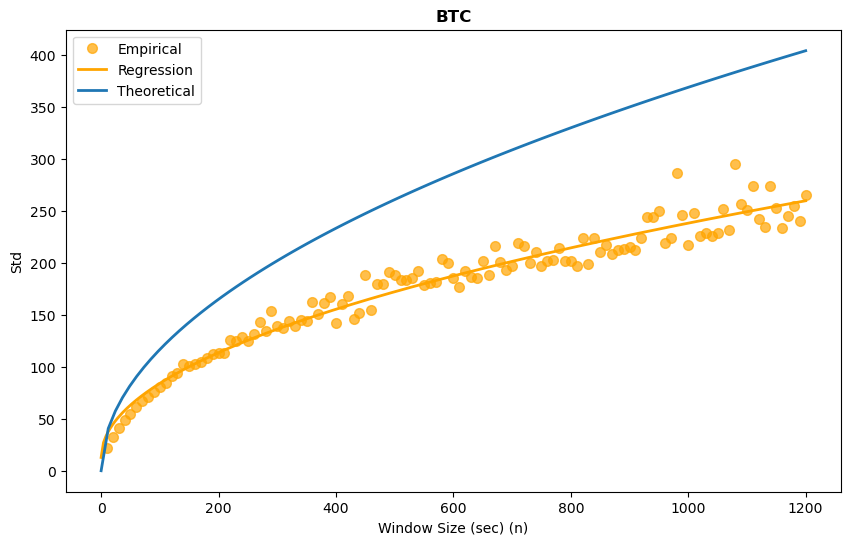

In [64]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) using only n >= 200
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x) (linear regression in transformed space)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

In [65]:
y_hat = np.sqrt(x)*par

In [66]:
MSE = np.array([(y[i]-y_hat[i])**2   for i in range(len(y_hat))])

In [67]:
MSE = np.sum(MSE) / len(MSE)

In [70]:
print(f"Mean Square Error: {MSE}")

Mean Square Error: 10059.98018738683


In [71]:
print(f"Percentage error:%{((par-7.123004)/7.123004)*100}")

Percentage error:%63.64256547896277
